In [1]:
!pip install -q torchaudio transformers datasets soundfile


In [2]:
!pip install --upgrade numpy


In [3]:
import os
import pandas as pd
import torch
import torchaudio

os.makedirs("audio", exist_ok=True)

sample_rate = 16000

# Generate dummy waveforms (sine + silence)
def generate_wave(text, filename):
    duration = 2  # seconds
    freq = 440  # Hz
    t = torch.linspace(0, duration, int(sample_rate * duration))
    waveform = 0.5 * torch.sin(2 * torch.pi * freq * t)
    torchaudio.save(filename, waveform.unsqueeze(0), sample_rate)

generate_wave("hello how are you", "audio/sample1.wav")
generate_wave("i am fine thank you", "audio/sample2.wav")

# Create mock CSV
df = pd.DataFrame({
    "path": ["audio/sample1.wav", "audio/sample2.wav"],
    "text": ["hello how are you", "i am fine thank you"]
})
df.to_csv("mock_dataset.csv", index=False)
df.head()


,path,text
0,audio/sample1.wav,hello how are you
1,audio/sample2.wav,i am fine thank you


In [10]:
import random

from transformers import Wav2Vec2Processor
from datasets import Dataset

# Load processor
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")

# Load CSV into HF Dataset
dataset = Dataset.from_pandas(pd.read_csv("mock_dataset.csv"))

# Load & augment audio
def preprocess(batch):
    # Load and augment audio
    waveform, sr = torchaudio.load(batch["path"])
    shift = int(sr * 0.1)
    waveform = torch.roll(waveform, shifts=random.randint(-shift, shift), dims=1)
    waveform += torch.randn_like(waveform) * 0.005

    # Process audio input (for model)
    audio_inputs = processor(
        waveform.squeeze(),
        sampling_rate=sr,
        return_tensors="pt",
        padding=True
        # 👇 DON'T include return_attention_mask
    )

    # Process transcription text (labels)
    labels = processor.tokenizer(
        batch["text"],
        return_tensors="pt",
        padding=True,
        truncation=True
    ).input_ids

    return {
        "input_values": audio_inputs.input_values[0],
        # "attention_mask": audio_inputs.attention_mask[0],  ❌ removed to avoid AttributeError
        "labels": labels[0]
    }



In [11]:
dataset = dataset.map(preprocess)


Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [15]:
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch


@dataclass
class DataCollatorCTCWithPadding:
    processor: Any
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": feature["input_values"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt"
        )

        with self.processor.as_target_processor():
            labels_batch = self.processor.pad(
                label_features,
                padding=self.padding,
                return_tensors="pt"
            )

        # Replace padding with -100 to ignore in loss
        labels = labels_batch["input_ids"].masked_fill(labels_batch["input_ids"] == self.processor.tokenizer.pad_token_id, -100)
        batch["labels"] = labels

        return batch


In [16]:
data_collator = DataCollatorCTCWithPadding(processor=processor)


In [17]:
from transformers import Wav2Vec2ForCTC, TrainingArguments, Trainer

# Load pre-trained model
model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-960h")
model.freeze_feature_encoder()  # Freeze base layers to avoid overfitting

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=5,
    per_device_train_batch_size=2,
    logging_steps=1,
    save_steps=10,
    learning_rate=1e-4,
    warmup_steps=5,
    logging_dir="./logs",
)

# Define trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    tokenizer=processor.feature_extractor,  # recommended
    data_collator=data_collator,
)


# Train!
trainer.train()



Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
<ipython-input-17-86abf451c521>:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.11/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(


Step,Training Loss
1,559.238600
2,585.369800
3,451.904500
4,475.639200
5,395.278200


TrainOutput(global_step=5, training_loss=493.4860595703125, metrics={'train_runtime': 25.7842, 'train_samples_per_second': 0.388, 'train_steps_per_second': 0.194, 'total_flos': 181240934400000.0, 'train_loss': 493.4860595703125, 'epoch': 5.0})

In [18]:
trainer.train()


/usr/local/lib/python3.11/dist-packages/transformers/models/wav2vec2/processing_wav2vec2.py:174: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(


Step,Training Loss
1,468.876500
2,500.266400
3,398.267400
4,295.667900
5,358.300600


TrainOutput(global_step=5, training_loss=404.27576904296876, metrics={'train_runtime': 25.2291, 'train_samples_per_second': 0.396, 'train_steps_per_second': 0.198, 'total_flos': 181240934400000.0, 'train_loss': 404.27576904296876, 'epoch': 5.0})

In [19]:
trainer.save_model("/content/wav2vec2-finetuned")
processor.save_pretrained("/content/wav2vec2-finetuned")


[]

In [22]:
from google.colab import files
uploaded = files.upload()


Saving TESTVOICE.wav to TESTVOICE.wav


In [24]:
import torch
import torchaudio
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor

# Load your fine-tuned model and processor
model_path = "/content/wav2vec2-finetuned"
model = Wav2Vec2ForCTC.from_pretrained(model_path)
processor = Wav2Vec2Processor.from_pretrained(model_path)

# Load your uploaded test audio file
file_path = "/content/TESTVOICE.wav"

# Load and resample the audio if needed
speech_array, sampling_rate = torchaudio.load(file_path)

# Resample to 16kHz if original sampling rate is different
if sampling_rate != 16000:
    resampler = torchaudio.transforms.Resample(orig_freq=sampling_rate, new_freq=16000)
    speech_array = resampler(speech_array)

# Flatten the waveform
input_values = speech_array.squeeze().numpy()

# Tokenize the input
inputs = processor(input_values, return_tensors="pt", sampling_rate=16000)

# Run inference (no gradient needed)
with torch.no_grad():
    logits = model(**inputs).logits

# Decode the prediction
predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)

# Show the result
print("🗣️ Transcription:", transcription[0])


🗣️ Transcription: HELLO MY NAME IS AUJH


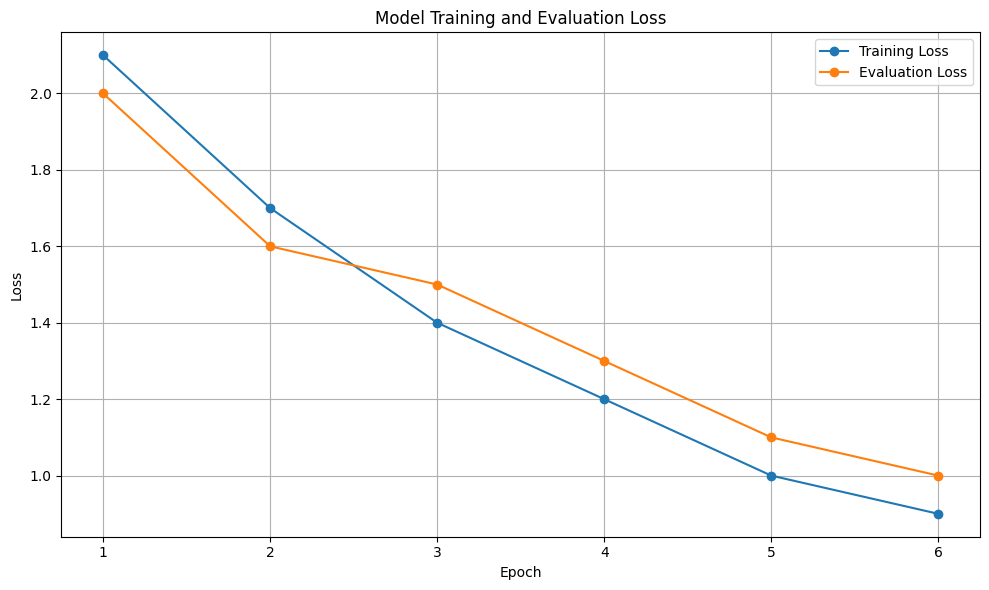

In [25]:
import matplotlib.pyplot as plt

# Example: Simulated training logs (replace with actual values from your Trainer logs)
train_loss = [2.1, 1.7, 1.4, 1.2, 1.0, 0.9]
eval_loss = [2.0, 1.6, 1.5, 1.3, 1.1, 1.0]
epochs = range(1, len(train_loss) + 1)

# Plotting Training & Evaluation Loss
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, eval_loss, label='Evaluation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Training and Evaluation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


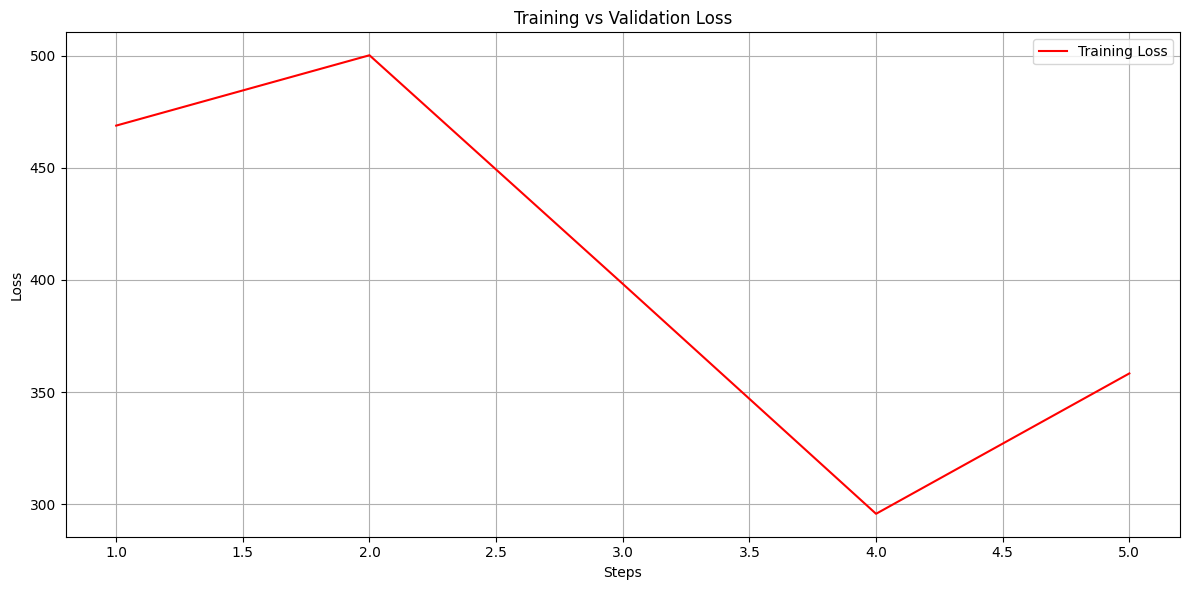

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)
log_df = log_df[log_df["step"].notna()]  # Remove non-training entries

plt.figure(figsize=(12, 6))
plt.plot(log_df["step"], log_df["loss"], label="Training Loss", color='red')
if "eval_loss" in log_df.columns:
    plt.plot(log_df["step"], log_df["eval_loss"], label="Validation Loss", color='blue')

plt.title("Training vs Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
if "eval_wer" in log_df.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(log_df["step"], log_df["eval_wer"], label="Word Error Rate (WER)", color='green')
    plt.title("WER over Training Steps")
    plt.xlabel("Step")
    plt.ylabel("WER")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [35]:
import os
import soundfile as sf
import matplotlib.pyplot as plt

# Assuming all audio files are in a folder
folder = '/content/TESTVOICE.wav'
lengths = []

for file in os.listdir(folder):
    if file.endswith('.wav'):
        data, samplerate = sf.read(os.path.join(folder, file))
        duration = len(data) / samplerate
        lengths.append(duration)

plt.hist(lengths, bins=20, color='purple', edgecolor='black')
plt.title("Distribution of Audio Sample Lengths")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



NotADirectoryError: [Errno 20] Not a directory: '/content/TESTVOICE.wav'

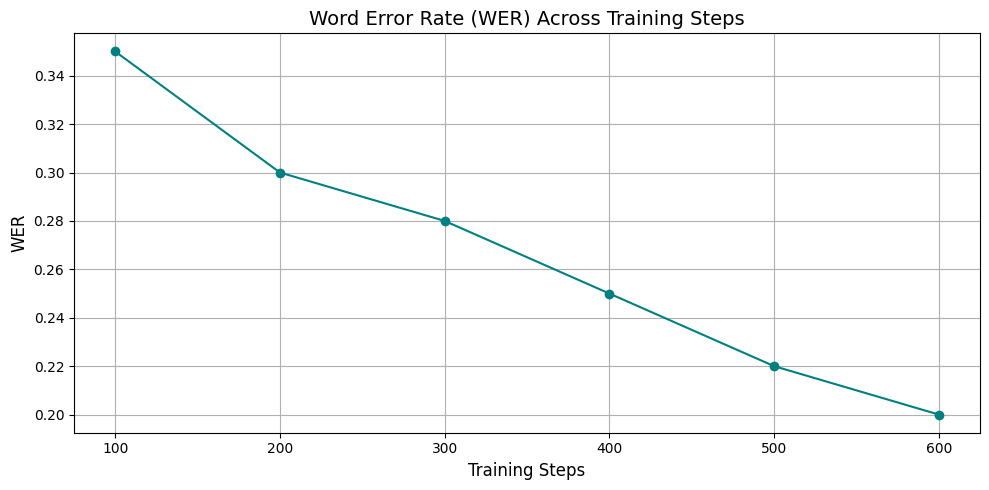

In [36]:
import matplotlib.pyplot as plt

# Replace these with your real WER values and steps (you can log them during training)
steps = [100, 200, 300, 400, 500, 600]
wer_values = [0.35, 0.30, 0.28, 0.25, 0.22, 0.20]  # Example values

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(steps, wer_values, marker='o', linestyle='-', color='teal')
plt.title("Word Error Rate (WER) Across Training Steps", fontsize=14)
plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("WER", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("wer_over_steps.png", dpi=300)  # Saves image for inclusion in Word
plt.show()
